In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import re
import json

data_dir = Path("/home/bjoern/Projects/Masterarbeit/simdata/server/baseline")

filename_pattern = re.compile(
    r"base(\d+)agent(\d+)_(\d+)-(\d+)#(\d+)"
)

rows = []

for file in data_dir.iterdir():

    if file.suffix != ".json":
        continue

    match = filename_pattern.match(file.stem)

    if not match:
        print(f"Skipping {file.name}")
        continue

    experiment, agent, start, goal, run = map(int, match.groups())

    with open(file) as f:
        data = json.load(f)

    info = data["info"]

    row = {
        "experiment": experiment,
        "agent": agent,
        "start": start,
        "goal": goal,
        "run": run,
        "movement": f"{start}-{goal}",
        "converged": data["trajectory"] is not None,
        "NJS": info.get("NJS"),
        "EE_NJS": info.get("Endeffector_NJS"),
    }

    traj = data["trajectory"]

    if traj is not None:

        points = traj["points"]
        joints = traj["joint_names"]

        start_pos = points[0]["positions"]
        end_pos = points[-1]["positions"]

        for joint, s, e in zip(joints, start_pos, end_pos):
            row[f"{joint}_disp"] = e - s

    rows.append(row)


df = pd.DataFrame(rows)
print(df.head())

   experiment  agent  start  goal  run movement  converged           NJS  \
0          13      1      3     6    2      3-6       True  1.698856e+07   
1          10      2      1     3    2      1-3       True  2.080785e+06   
2          34      1      3     7    1      3-7      False           NaN   
3           2      1      3     5    1      3-5       True  5.999101e+06   
4          46      1      3     7    1      3-7      False           NaN   

       EE_NJS  columna_rot_joint_disp  columna_flex_joint_disp  \
0  161.275011                0.233775                 0.219426   
1   47.969835               -0.055978                 0.455981   
2   49.867416                     NaN                      NaN   
3  279.305360                0.160715                 0.223167   
4   90.583766                     NaN                      NaN   

   sternoclavicular_yaw_joint_disp  sternoclavicular_pitch_joint_disp  \
0                         0.049633                          -0.049827   


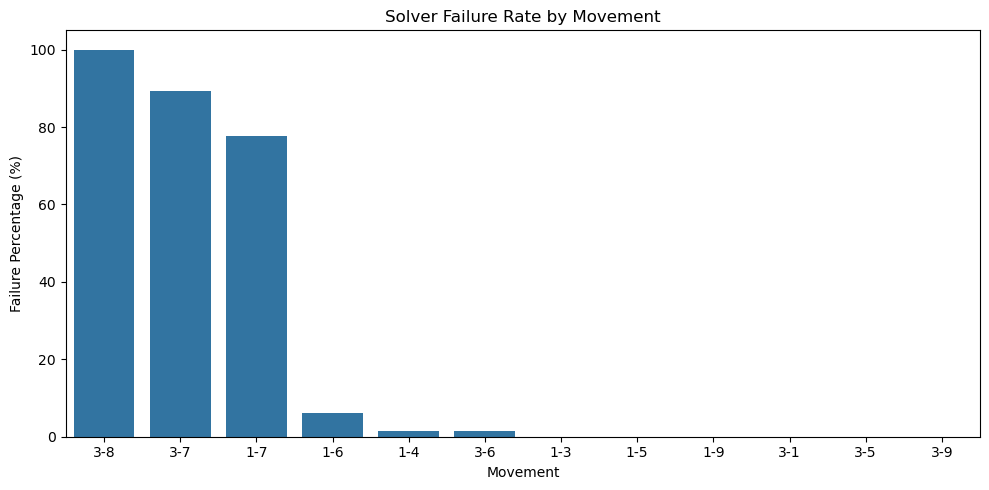

In [4]:
df["failure"] = ~df["converged"]

failure_rates = (
    df.groupby("movement")["failure"]
      .mean()
      .mul(100)
      .reset_index(name="failure_percent")
      .sort_values("failure_percent", ascending=False)
)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=failure_rates,
    x="movement",
    y="failure_percent"
)

plt.ylabel("Failure Percentage (%)")
plt.xlabel("Movement")
plt.title("Solver Failure Rate by Movement")

plt.tight_layout()
plt.show()

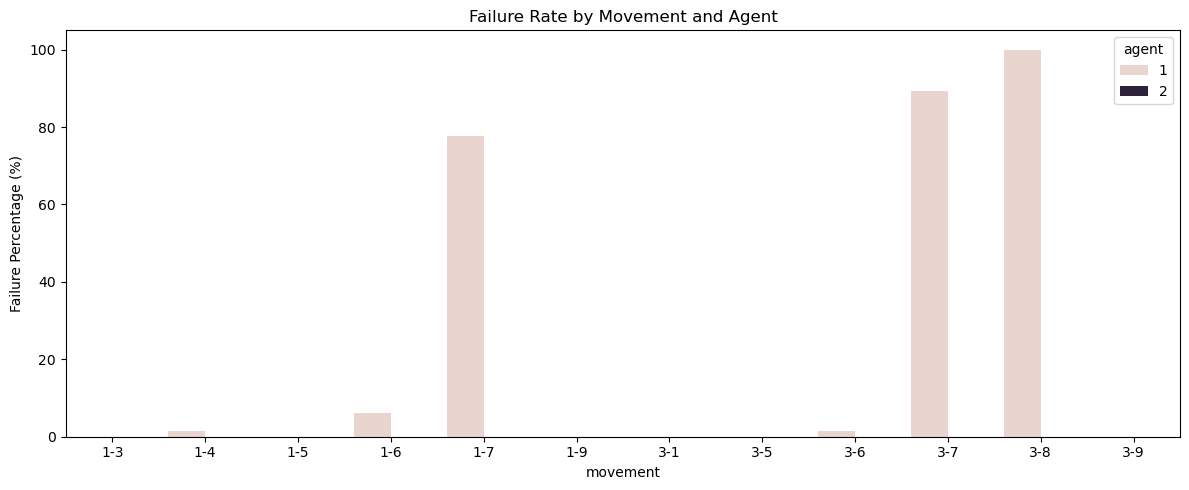

In [5]:
failure_rates = (
    df.groupby(["movement", "agent"])["failure"]
      .mean()
      .mul(100)
      .reset_index(name="failure_percent")
)

plt.figure(figsize=(12, 5))

sns.barplot(
    data=failure_rates,
    x="movement",
    y="failure_percent",
    hue="agent"
)

plt.ylabel("Failure Percentage (%)")
plt.title("Failure Rate by Movement and Agent")

plt.tight_layout()
plt.show()

In [8]:
print(df["agent"].value_counts())
print(df["agent"].value_counts())
print(df.groupby("agent")["movement"].unique())

agent
1    861
2    115
Name: count, dtype: int64
agent
1    861
2    115
Name: count, dtype: int64
agent
1    [3-6, 3-7, 3-5, 3-1, 1-3, 3-8, 1-6, 1-9, 3-9, ...
2                                                [1-3]
Name: movement, dtype: object
